# Notebook 01 — Exploratory Data Analysis
## Selective Prediction under Uncertainty

This notebook explores the dataset structure, class imbalance, feature distributions,
and confidence-estimation properties of baseline classifiers.

**Key questions:**
- How severe is the class imbalance?
- Which features carry the most signal?
- Where does a naive classifier struggle (high-uncertainty region)?


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from src.preprocessing import load_raw_dataset, engineer_features, split_and_scale
from src.utils import set_seed

set_seed(42)
print('Imports OK')


Imports OK


## 1. Load & Inspect Dataset

In [2]:
df = load_raw_dataset()
df = engineer_features(df)
print(f'Shape: {df.shape}')
print(f'Fraud rate: {df["Class"].mean():.3%}')
df.head()


[12:24:58] WARNING | src.preprocessing | Real dataset not found. Generating synthetic fallback (20 000 samples, 5 %% fraud rate).


Shape: (20000, 13)
Fraud rate: 5.000%


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Hour,Class,log_Amount
0,-0.162490,-0.683136,1.455208,1.167441,-1.009430,-0.383503,0.063476,0.321441,0.659437,-0.268091,5.0,0,4.195322
1,-0.825777,-1.876105,0.432711,-0.173727,-0.713693,-0.964040,-0.238575,0.469996,-0.329983,-1.188526,9.0,0,6.293544
2,-0.791766,1.364156,-0.456307,0.895433,0.063100,-0.777291,2.167553,1.236089,-0.213939,0.921176,0.0,0,4.029081
3,-0.367723,-0.156883,0.429363,1.695772,-0.530854,-0.757610,-1.378809,0.103096,-1.405687,-0.463783,8.0,0,4.886547
4,-0.698311,-0.247063,-2.350955,-0.567035,0.467353,-1.618800,0.259860,1.408271,0.144588,-0.144240,16.0,0,4.652215


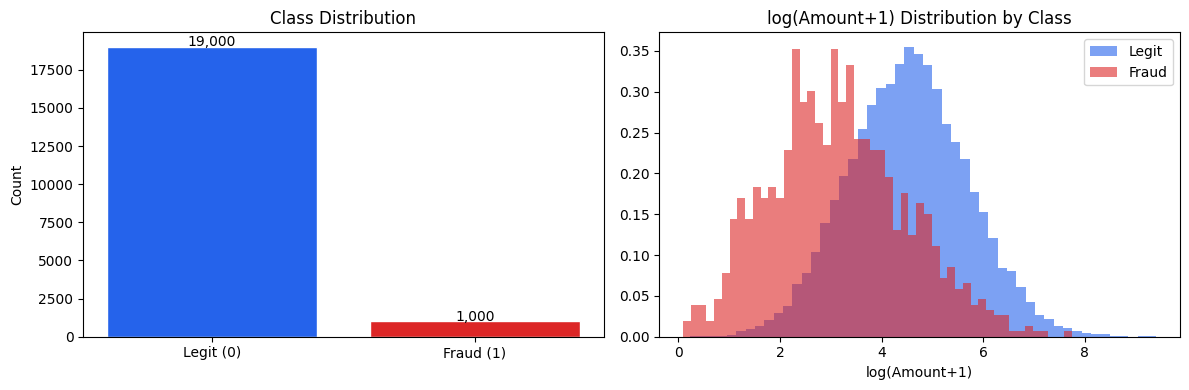

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class imbalance bar
counts = df['Class'].value_counts()
axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values,
            color=['#2563EB', '#DC2626'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# log-Amount distribution
for label, color in [(0, '#2563EB'), (1, '#DC2626')]:
    subset = df[df['Class'] == label]['log_Amount']
    axes[1].hist(subset, bins=50, alpha=0.6, color=color,
                 label='Legit' if label == 0 else 'Fraud', density=True)
axes[1].set_title('log(Amount+1) Distribution by Class')
axes[1].set_xlabel('log(Amount+1)')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2. Feature Correlation Heatmap

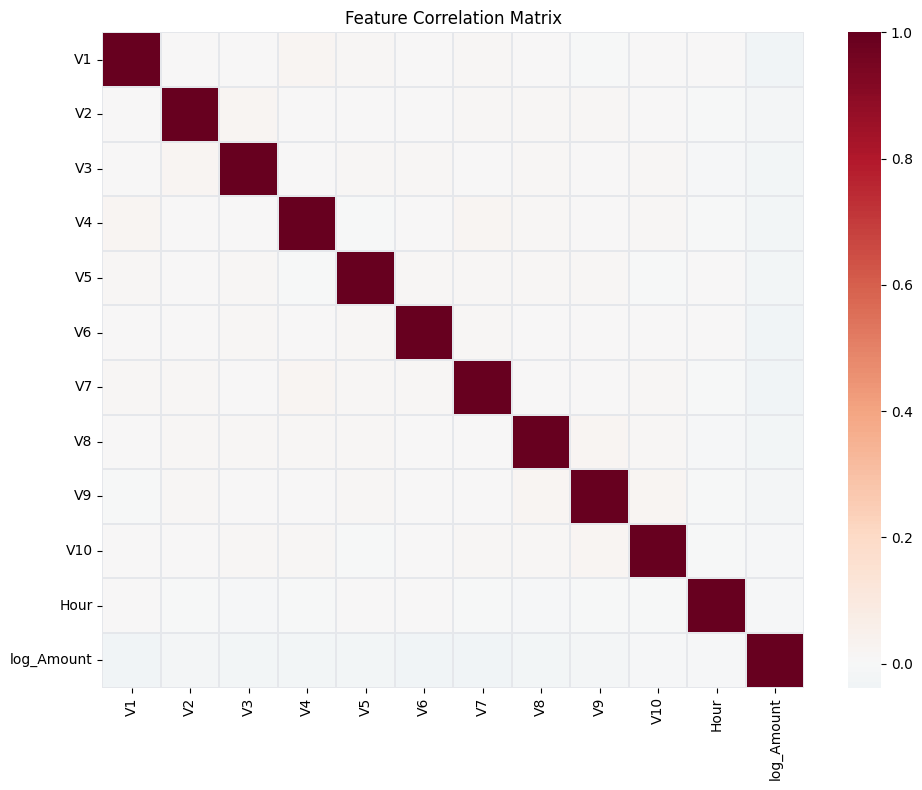

In [4]:
feat_cols = [c for c in df.columns if c not in ('Class',)]
corr = df[feat_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax,
            xticklabels=corr.columns, yticklabels=corr.columns,
            linewidths=0.3, linecolor='#e5e7eb')
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()


## 3. Train/Test Split & Baseline Model

In [5]:
splits = split_and_scale(df)
print(f'Train: {splits["X_train"].shape}, Val: {splits["X_val"].shape}, Test: {splits["X_test"].shape}')
print(f'Fraud rate — Train: {splits["y_train"].mean():.3%}, Test: {splits["y_test"].mean():.3%}')


Train: (14000, 12), Val: (2000, 12), Test: (4000, 12)
Fraud rate — Train: 5.000%, Test: 5.000%


In [6]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(splits['X_train'], splits['y_train'])
y_pred = lr.predict(splits['X_test'])
print(classification_report(splits['y_test'], y_pred, target_names=['Legit', 'Fraud']))


              precision    recall  f1-score   support

       Legit       0.99      0.81      0.89      3800
       Fraud       0.19      0.84      0.30       200

    accuracy                           0.81      4000
   macro avg       0.59      0.82      0.60      4000
weighted avg       0.95      0.81      0.86      4000



## 4. Confidence Distribution Preview

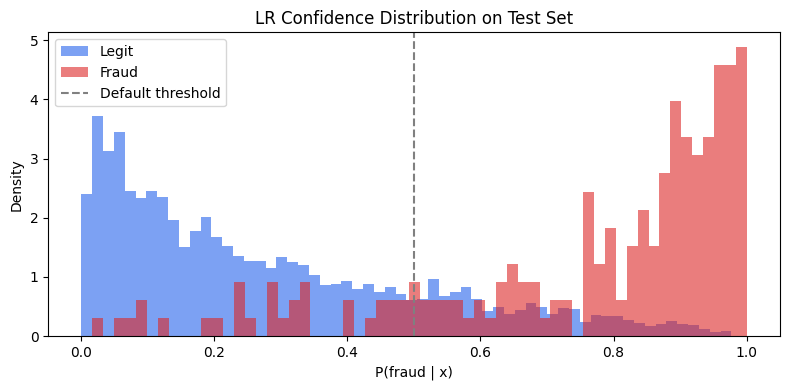


High-uncertainty samples (0.3 < P < 0.7): 30.1%


In [7]:
proba = lr.predict_proba(splits['X_test'])[:, 1]
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, lbl in [(0, '#2563EB', 'Legit'), (1, '#DC2626', 'Fraud')]:
    mask = splits['y_test'] == label
    ax.hist(proba[mask], bins=60, density=True, alpha=0.6, color=color, label=lbl)
ax.axvline(0.5, ls='--', lw=1.5, color='gray', label='Default threshold')
ax.set_xlabel('P(fraud | x)'); ax.set_ylabel('Density')
ax.set_title('LR Confidence Distribution on Test Set')
ax.legend(); plt.tight_layout(); plt.show()

print(f'\nHigh-uncertainty samples (0.3 < P < 0.7): '
      f'{((proba > 0.3) & (proba < 0.7)).mean():.1%}')


## Takeaways

- The dataset has severe class imbalance (~5% fraud), making threshold selection critical.
- A meaningful portion of test samples fall in the uncertain region (0.3–0.7 probability).
- These samples are prime candidates for selective abstention — explored in Notebook 02.
